In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/4-data_wrangling-heart/Heart_disease_cleveland_new.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [39]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [40]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [41]:
#if there is any missing value
#df.fillna(df.median(numeric_only=True), inplace=True)

In [42]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [43]:
df = df.apply(pd.to_numeric)

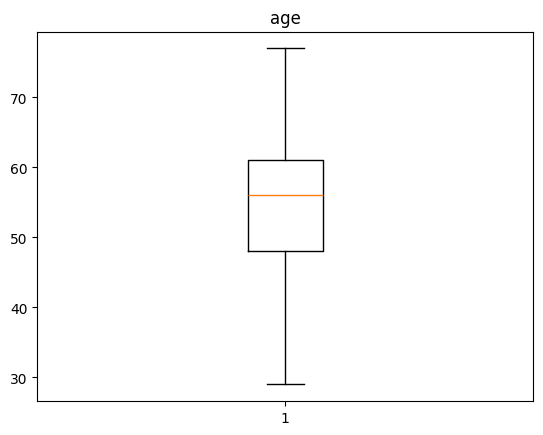

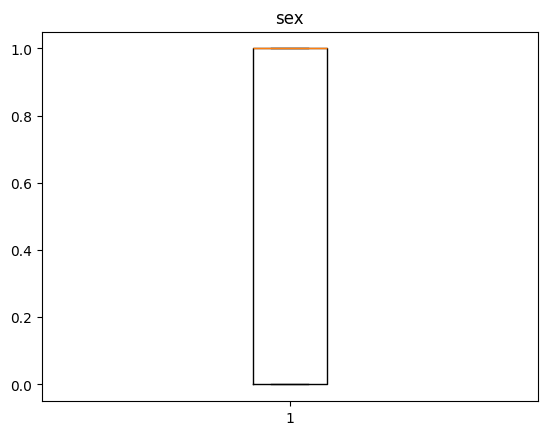

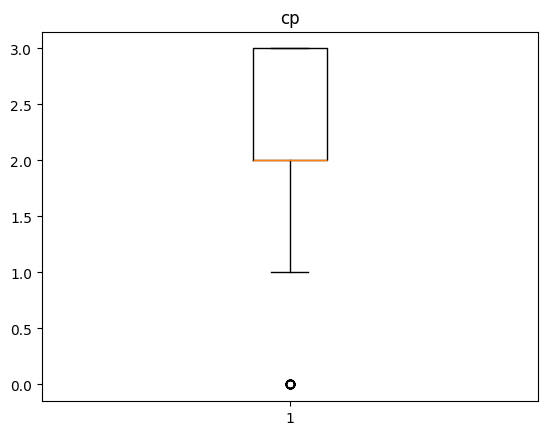

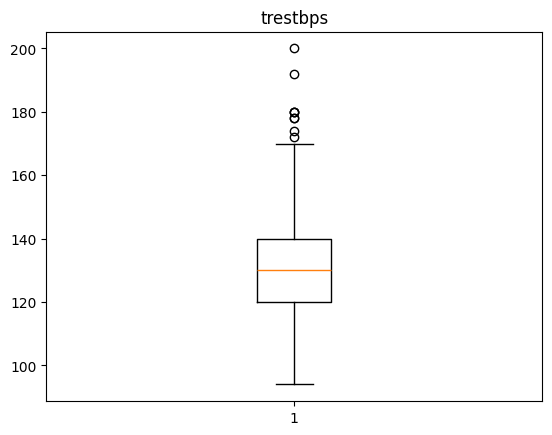

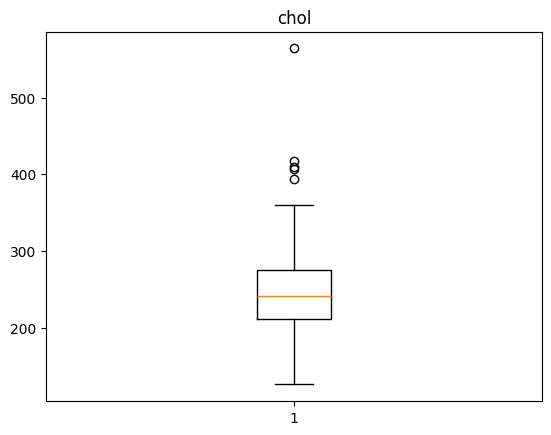

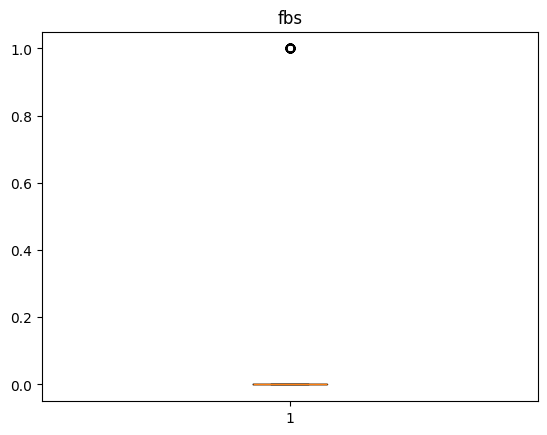

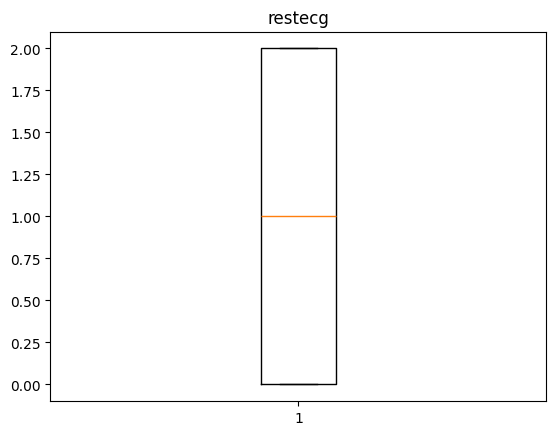

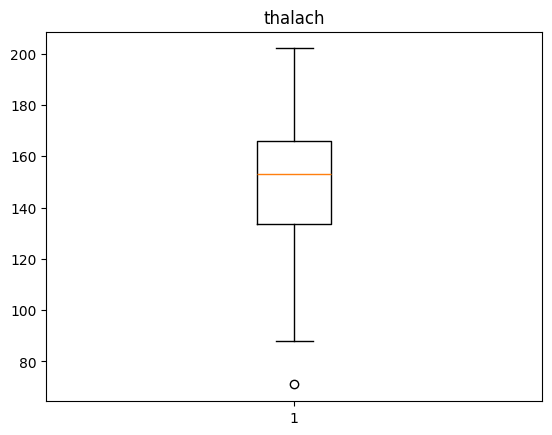

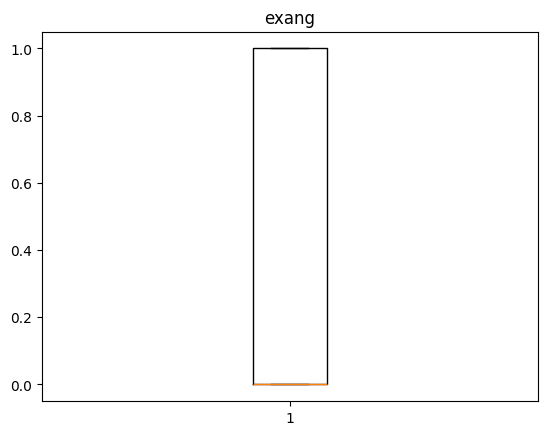

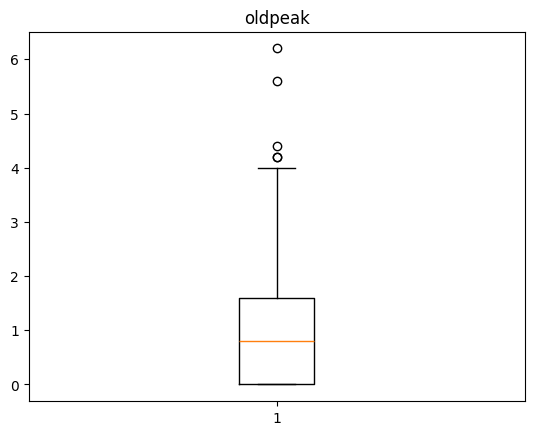

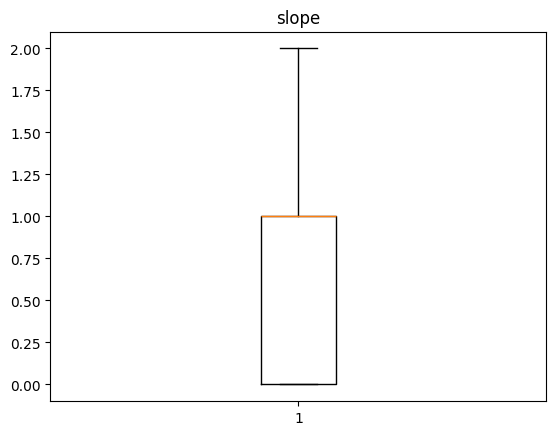

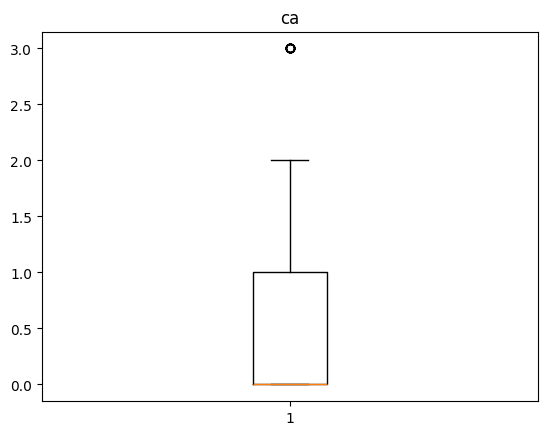

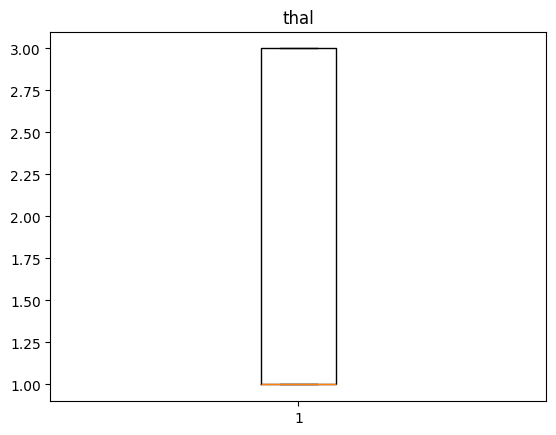

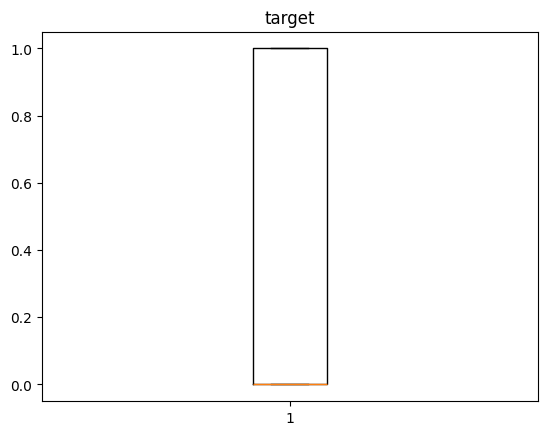

In [44]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [45]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
sex: 0 outliers
cp: 23 outliers
trestbps: 9 outliers
chol: 5 outliers
fbs: 45 outliers
restecg: 0 outliers
thalach: 1 outliers
exang: 0 outliers
oldpeak: 5 outliers
slope: 0 outliers
ca: 20 outliers
thal: 0 outliers
target: 0 outliers


In [46]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

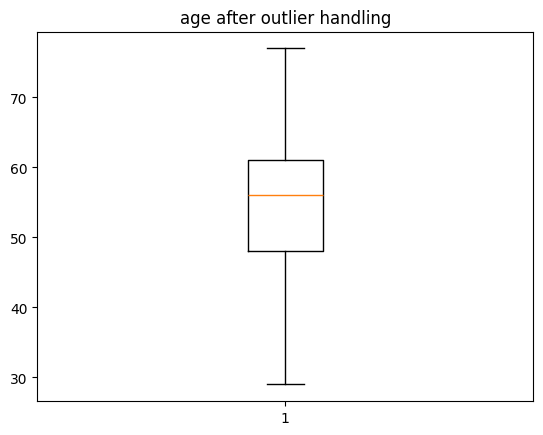

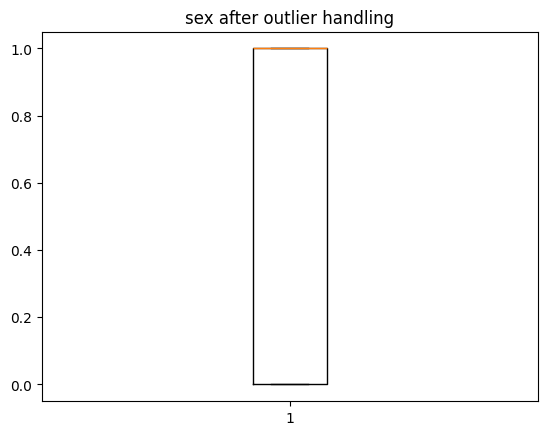

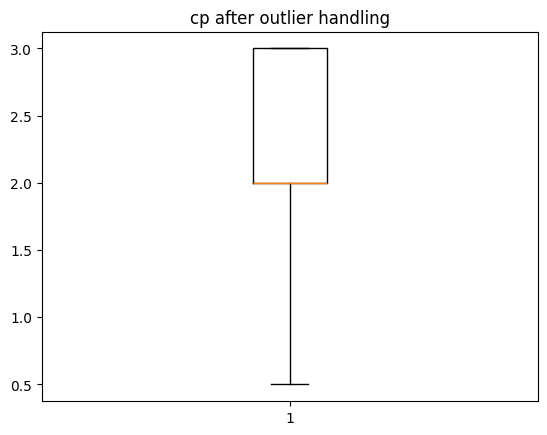

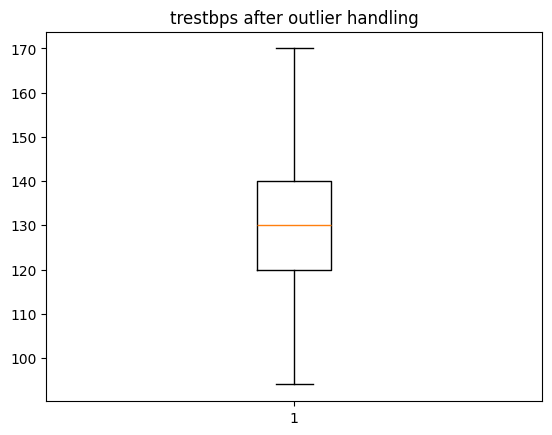

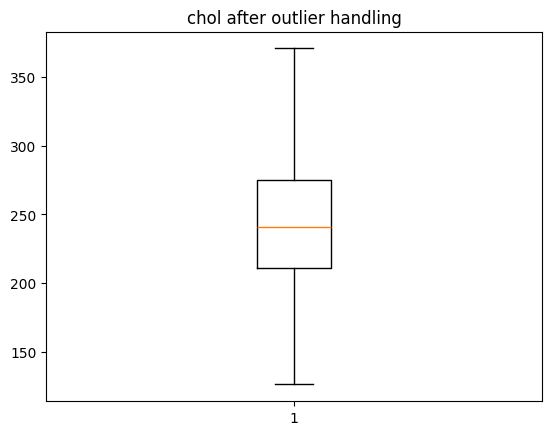

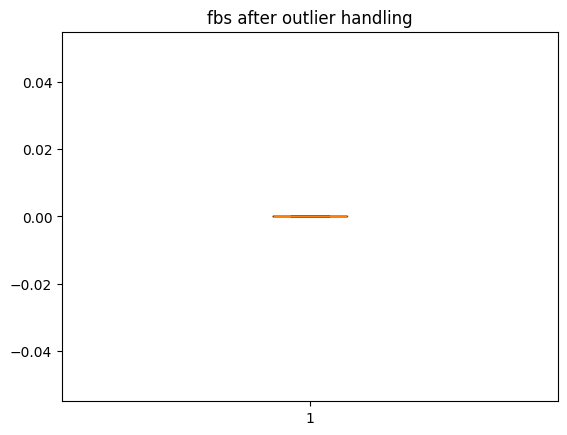

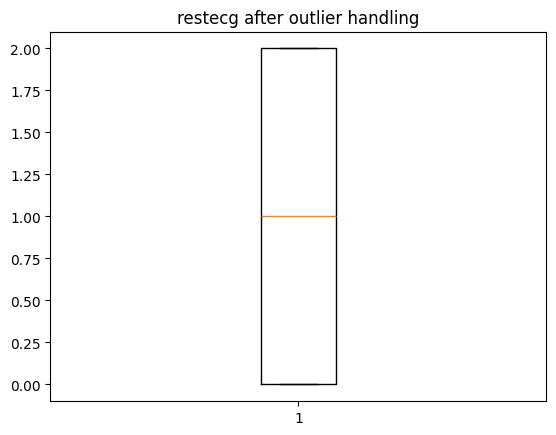

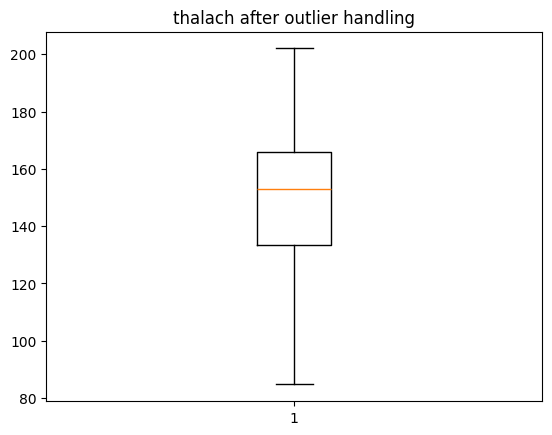

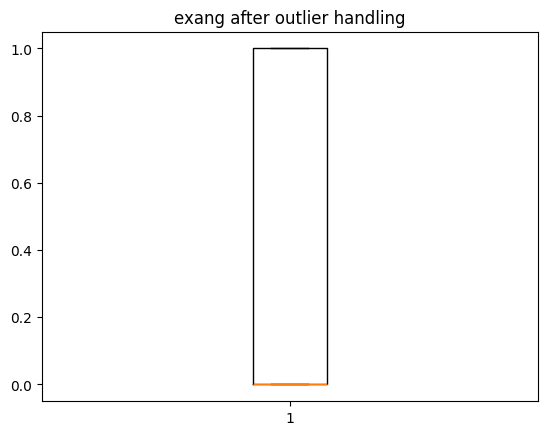

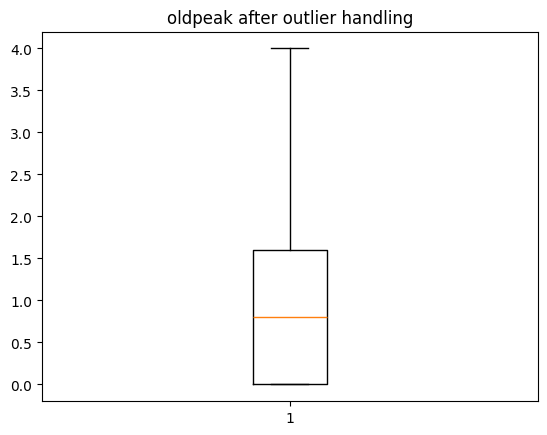

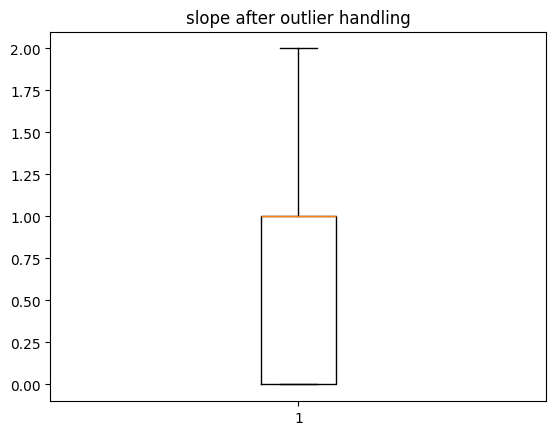

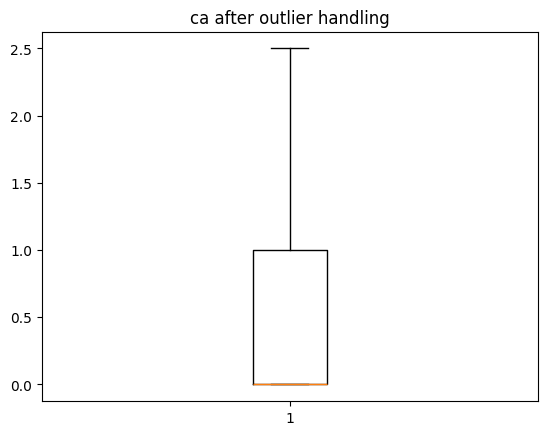

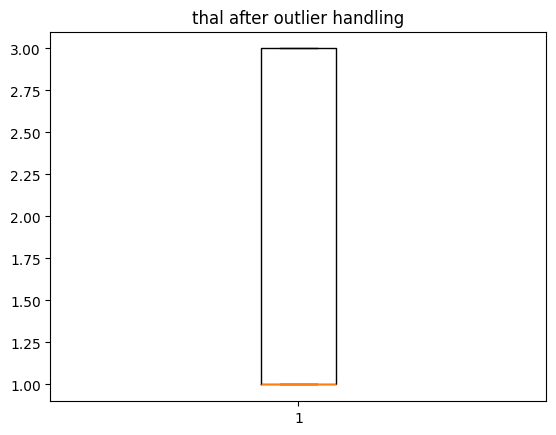

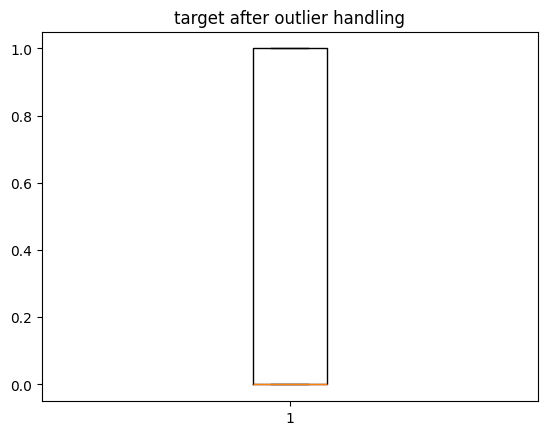

In [47]:
numeric_cols = df.select_dtypes(include="number").columns
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"{col} after outlier handling")
    plt.show()

In [48]:
print(df.skew())

age        -0.209060
sex        -0.774935
cp         -0.604821
trestbps    0.383341
chol        0.331040
fbs         0.000000
restecg     0.019900
thalach    -0.493287
exang       0.742532
oldpeak     0.997885
slope       0.508316
ca          0.989215
thal        0.342673
target      0.166406
dtype: float64


In [49]:
df["oldpeak_log"] = np.log1p(df["oldpeak"])

print("Before:", df["oldpeak"].skew())
print("After:", df["oldpeak_log"].skew())

Before: 0.9978850875188225
After: 0.34611548340773546


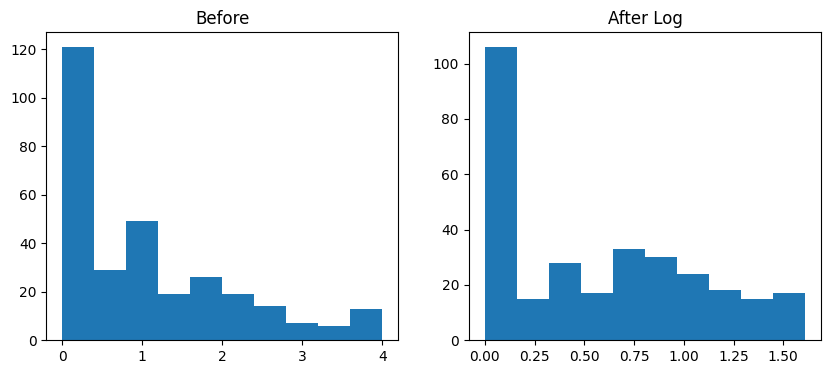

In [50]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["oldpeak"])
plt.title("Before")

plt.subplot(1,2,2)
plt.hist(df["oldpeak_log"])
plt.title("After Log")

plt.show()

In [51]:
df["age_scaled"] = df["age"] / 100

In [52]:
df["oldpeak_norm"] = (
    df["oldpeak"] - df["oldpeak"].min()
) / (
    df["oldpeak"].max() - df["oldpeak"].min()
)